In [1]:
import torch
import deepxde as dde

%cd ..
from models import FNO2d

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


/home/tp526/neuraloperator/PI-FNO-reproduce


<h2>Load model and format data</h2>

In [2]:
# Function to load
def load_model(ckpt_path, config):
    model = FNO2d(modes1=config['model']['modes1'],
              modes2=config['model']['modes2'],
              fc_dim=config['model']['fc_dim'],
              layers=config['model']['layers'],
              act=config['model']['act']).to(device)

    ckpt = torch.load(ckpt_path)
    model.load_state_dict(ckpt['model'])

    print("-" * 100)
    print("\nNumber of trainable parameters: ", sum(p.numel() for p in model.parameters()))
    print("\n" + "-" * 100)

    return model

In [4]:
# Usage
config = {"model": {
              "layers": [12, 12, 16 ], #[16, 24, 24, 32, 32],
              "modes1": [8, 6, 4],
              "modes2": [8, 6, 4],
              "fc_dim": 32,
              "act": "gelu",
              "num_pad": 4,
            },
          }

advection = load_model("/home/tp526/neuraloperator/PI-FNO-reproduce/checkpoints/Paper-models/advection-physics.pt",
                        config
                       )

----------------------------------------------------------------------------------------------------

Number of trainable parameters:  33757

----------------------------------------------------------------------------------------------------


In [3]:
# Function to format data
def format_data(data_dict):
    """
    Reshapes the Burgers dataset into a coordinate-based format.
    
    Args:
        data_dict (dict): Dictionary with keys 'x' (N, Nx) and 'y' (N, Nt, Nx).
        
    Returns:
        np.array: A single array of shape (N_SAMPLES, Nt, Nx, 3).
                  Channel 0: u0(x) repeated over time
                  Channel 1: x coordinates
                  Channel 2: t coordinates
    """
    # 1. Extract dimensions
    # data_dict['x'] is the initial condition u0, shape (N, Nx)
    # data_dict['y'] is the solution u, shape (N, Nt, Nx)
    u0 = data_dict['x'] 
    N_samples, Nx = u0.shape
    Nt = data_dict['y'].shape[1]
    
    print(f"Dimensions detected: N={N_samples}, Nt={Nt}, Nx={Nx}")

    # 2. Create Mesh Grids (Nt, Nx)
    # Recreate the grids used in the solver
    x_1d = np.linspace(0, 1, Nx, endpoint=False)
    t_1d = np.linspace(0, 1, Nt)
    
    # Create 2D grids. indexing='ij' ensures output is (Nt, Nx)
    # T_grid varies along axis 0, X_grid varies along axis 1
    T_grid, X_grid = np.meshgrid(t_1d, x_1d, indexing='ij')
    
    # 3. Broadcast/Repeat Arrays to shape (N, Nt, Nx)
    
    # Channel 0: u0 (Initial Condition)
    # Input: (N, Nx) -> Expand to (N, 1, Nx) -> Tile to (N, Nt, Nx)
    u0_expanded = np.tile(u0[:, None, :], (1, Nt, 1))
    
    # Channel 1: X Grid
    # Input: (Nt, Nx) -> Expand to (1, Nt, Nx) -> Broadcast to (N, Nt, Nx)
    X_expanded = np.tile(X_grid[None, :, :], (N_samples, 1, 1))
    
    # Channel 2: T Grid
    # Input: (Nt, Nx) -> Expand to (1, Nt, Nx) -> Broadcast to (N, Nt, Nx)
    T_expanded = np.tile(T_grid[None, :, :], (N_samples, 1, 1))
    
    # 4. Stack along the last axis
    # Result shape: (N, Nt, Nx, 3, 1)
    formatted_data = np.stack([u0_expanded, X_expanded, T_expanded], axis=-1)
    
    return formatted_data

<h2>Eval and plot</h2>

In [22]:
# Evaluation of relative error

def eval_all(model, mat_dict):
    data_dict = {
        'x' : mat_dict['output'][:, 0, :],
        'y' : mat_dict['output']
    }

    formatted_inputs = format_data(data_dict)

    N_CASE = formatted_inputs.shape[0]

    l2_errors = np.zeros(N_CASE)
    l1_errors = np.zeros(N_CASE)

    with torch.no_grad():
    
        for k in range(N_CASE):
            x = torch.tensor(formatted_inputs[k:k+1], dtype=torch.float32).to(device)
            y = torch.tensor(data_dict["y"][k:k+1], dtype=torch.float32).to(device)

            out = model(x).reshape(y.shape)

            # Relative L2
            l2 = torch.norm(out - y, p=2) / torch.norm(y, p=2)
            l2_errors[k] = l2.item()

            # Relative L1
            l1 = torch.norm(out - y, p=1) / torch.norm(y, p=1)
            l1_errors[k] = l1.item()

    print("-" * 100)
    print(f"Mean L2-relative-error over 1000 tests: {np.mean(l2_errors):.6f}")
    print(f"Mean L1-relative-error over 1000 tests: {np.mean(l1_errors):.6f}")
    print("-" * 100)

    return np.mean(l1_errors), np.mean(l2_errors)

In [13]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# Function to plot
def plot_case(model, mat_dict, case, p=1):
    data_dict = {
        'x' : mat_dict['output'][:, 0, :],
        'y' : mat_dict['output']
    }

    formatted_inputs = format_data(data_dict)

    # grid of predictions
    k = case
    x, y = torch.tensor(formatted_inputs[k:k+1], dtype=torch.float32).to(device), torch.tensor(data_dict["y"][k:k+1], dtype=torch.float32).to(device)

    # Prediction
    out = model(x).reshape(y.shape)

    data_loss = torch.norm(out - y, p=p) / torch.norm(y, p=p)

    u_truth = y[0].detach().cpu().numpy()
    u_pred = out[0].detach().cpu().numpy()

    # Calculate error
    err = np.abs(u_pred - u_truth)

    plt.figure(figsize=(18, 5))

    # --- 1. Truth ---
    plt.subplot(1, 3, 1)
    im1 = plt.imshow(u_truth, extent=[0, 1, 0, 1], origin="lower", aspect="auto", cmap="jet", vmin=np.min(u_truth), vmax=np.max(u_truth))
    plt.title("Truth", fontsize=16)
    plt.axis('off')
    cbar1 = plt.colorbar(im1)
    cbar1.ax.tick_params(labelsize=14)

    # --- 2. Prediction ---
    plt.subplot(1, 3, 2)
    im2 = plt.imshow(u_pred, extent=[0, 1, 0, 1], origin="lower", aspect="auto", cmap="jet", vmin=np.min(u_truth), vmax=np.max(u_truth))
    plt.title("Prediction", fontsize=16)
    plt.axis('off')
    cbar2 = plt.colorbar(im2)
    cbar2.ax.tick_params(labelsize=14)

    # --- 3. Error (Log Scale) ---
    plt.subplot(1, 3, 3)
    # Note: LogNorm requires values > 0. We add a tiny epsilon (1e-10) to avoid log(0)
    im3 = plt.imshow(err + 1e-10, extent=[0, 1, 0, 1], origin="lower", aspect="auto", 
                 cmap="magma", norm=colors.LogNorm(vmin=1e-6, vmax=err.max()))
    plt.title("Absolute Error (Log Scale)", fontsize=16)
    plt.axis('off')
    cbar3 = plt.colorbar(im3)
    cbar3.ax.tick_params(labelsize=14)

    plt.tight_layout()
    plt.show()

    print("L1-relative erros: ", data_loss) 

In [8]:
import scipy 

mat_data = scipy.io.loadmat("/home/tp526/neuraloperator/data/test_data/advection_truth_x100_t101_1000.mat")

Dimensions detected: N=1000, Nt=101, Nx=100
----------------------------------------------------------------------------------------------------
Mean L2-relative-error over 1000 tests: 0.034632
Mean L1-relative-error over 1000 tests: 0.027824
----------------------------------------------------------------------------------------------------
Dimensions detected: N=1000, Nt=101, Nx=100


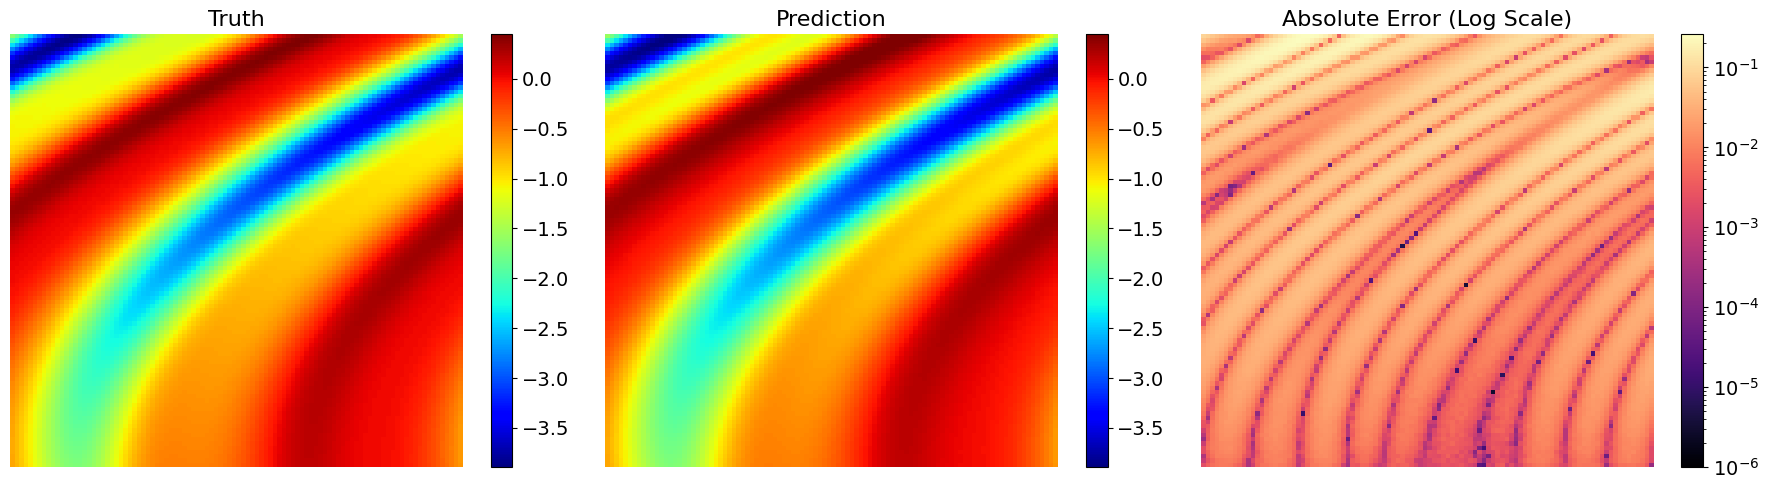

L1-relative erros:  tensor(0.0366, device='cuda:0', grad_fn=<DivBackward0>)


In [ ]:
# usage

error_advection_1 = eval_all(advection, mat_data)[1]

plot_case(advection, mat_data, case=200, p=2)

<h2>Test advection</h2>

In [16]:
# Load models

config = {"model": {
              "layers": [12, 12, 16 ], #[16, 24, 24, 32, 32],
              "modes1": [8, 6, 4],
              "modes2": [8, 6, 4],
              "fc_dim": 32,
              "act": "gelu",
              "num_pad": 4,
            },
          }

advection_0 = load_model("/home/tp526/neuraloperator/PI-FNO-reproduce/checkpoints/Paper-models/advection-physics.pt",
                        config
                        )
advection_1 = load_model("/home/tp526/neuraloperator/PI-FNO-reproduce/checkpoints/Paper-models/advection-physic-1.pt",
                        config
                        )
advection_2 = load_model("/home/tp526/neuraloperator/PI-FNO-reproduce/checkpoints/Paper-models/advection-physic-2.pt",
                        config
                        )

----------------------------------------------------------------------------------------------------

Number of trainable parameters:  33757

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------

Number of trainable parameters:  33757

----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------

Number of trainable parameters:  33757

----------------------------------------------------------------------------------------------------


In [17]:
import scipy

mat_data = scipy.io.loadmat("/home/tp526/neuraloperator/data/test_data/advection_truth_x100_t101_1000.mat")

Dimensions detected: N=1000, Nt=101, Nx=100


----------------------------------------------------------------------------------------------------
Mean L2-relative-error over 1000 tests: 0.034632
Mean L1-relative-error over 1000 tests: 0.027824
----------------------------------------------------------------------------------------------------
Dimensions detected: N=1000, Nt=101, Nx=100


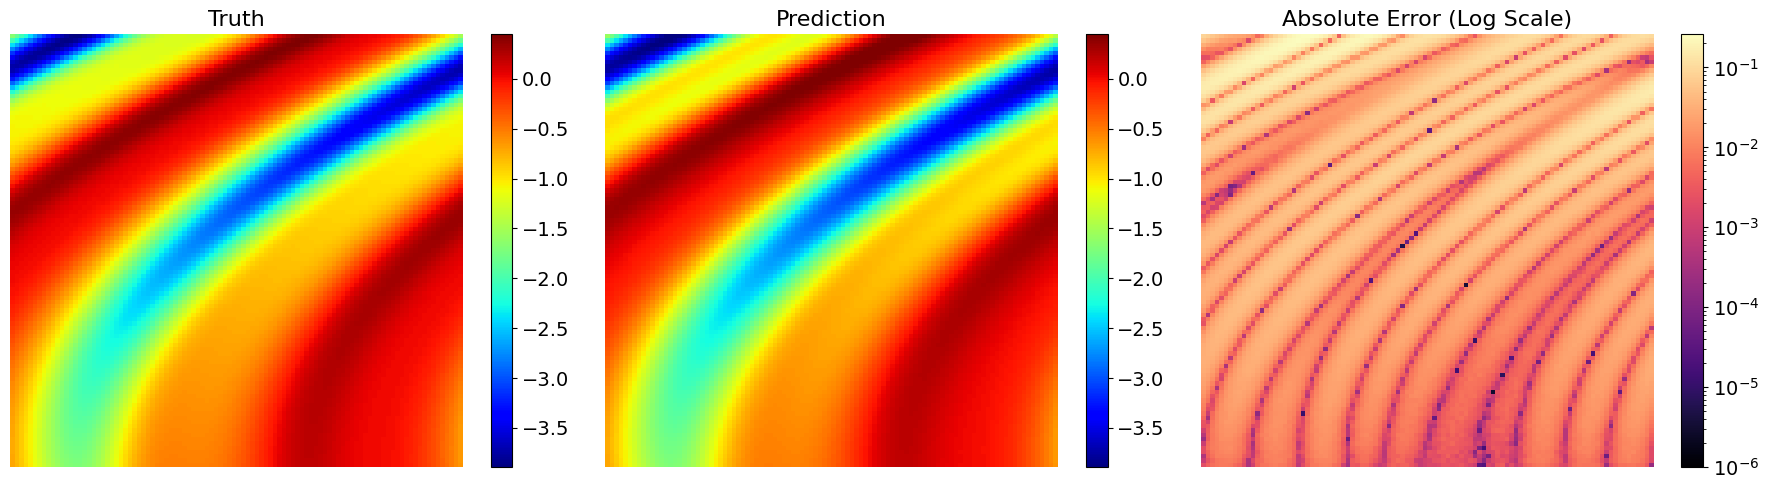

L1-relative erros:  tensor(0.0366, device='cuda:0', grad_fn=<DivBackward0>)
Dimensions detected: N=1000, Nt=101, Nx=100
----------------------------------------------------------------------------------------------------
Mean L2-relative-error over 1000 tests: 0.038534
Mean L1-relative-error over 1000 tests: 0.032493
----------------------------------------------------------------------------------------------------
Dimensions detected: N=1000, Nt=101, Nx=100


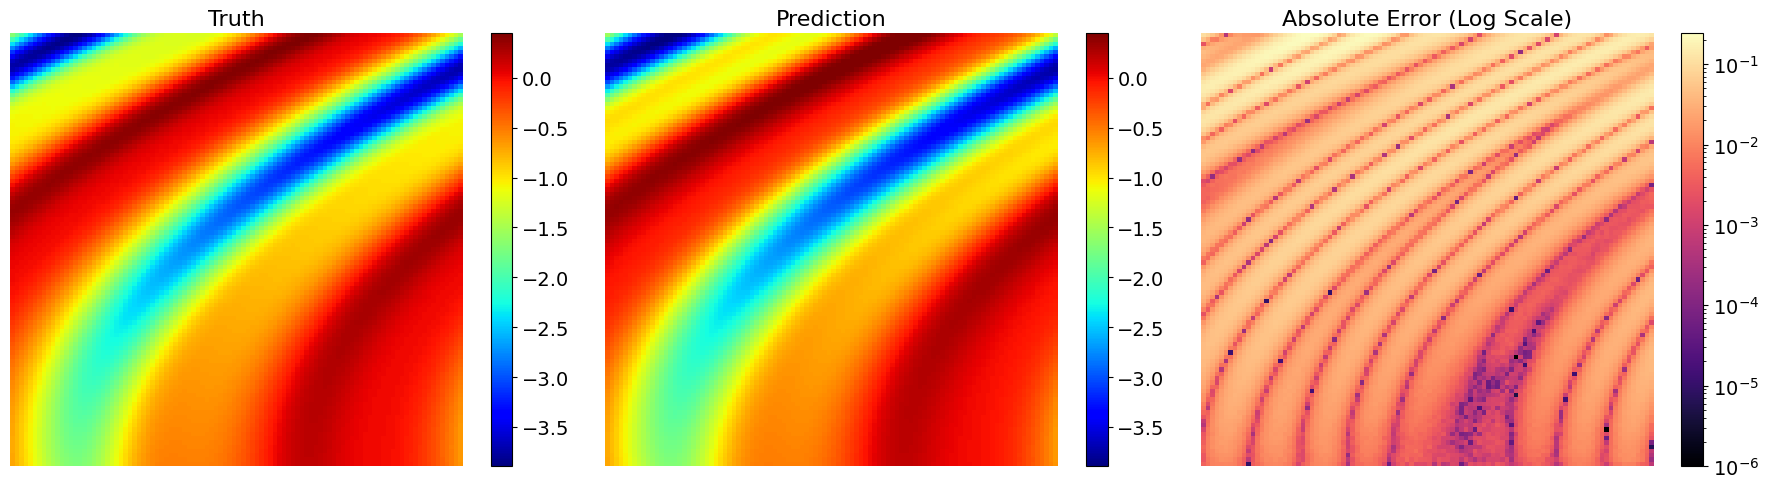

L1-relative erros:  tensor(0.0405, device='cuda:0', grad_fn=<DivBackward0>)
Dimensions detected: N=1000, Nt=101, Nx=100
----------------------------------------------------------------------------------------------------
Mean L2-relative-error over 1000 tests: 0.036757
Mean L1-relative-error over 1000 tests: 0.030353
----------------------------------------------------------------------------------------------------
Dimensions detected: N=1000, Nt=101, Nx=100


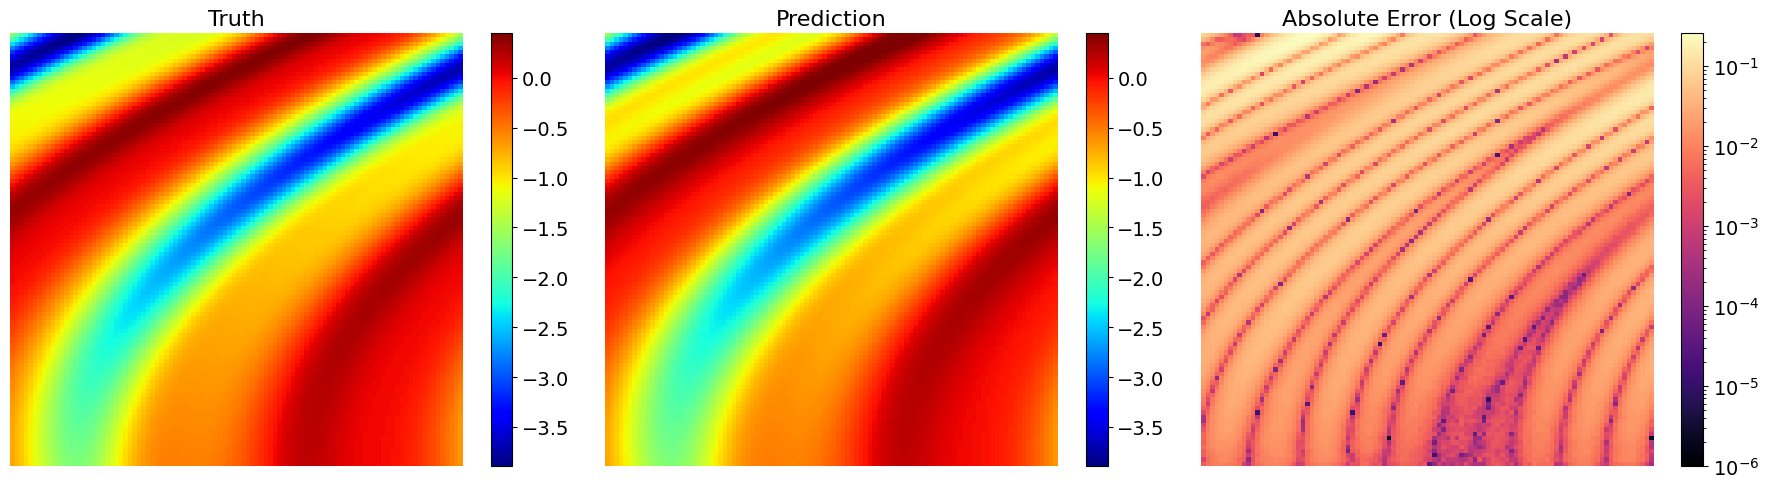

L1-relative erros:  tensor(0.0381, device='cuda:0', grad_fn=<DivBackward0>)


In [23]:
# Compute errors

# model 0
error_adv_0 = eval_all(advection_0, mat_data)[1]

plot_case(advection_0, mat_data, case=200, p=2)

# model 1
error_adv_1 = eval_all(advection_1, mat_data)[1]

plot_case(advection_1, mat_data, case=200, p=2)

# model 2
error_adv_2 = eval_all(advection_2, mat_data)[1]

plot_case(advection_2, mat_data, case=200, p=2)

In [24]:
errors = np.array([error_adv_0, error_adv_1, error_adv_2])

print("Mean error: ", np.mean(errors))
print("Std: ", np.std(errors))

Mean error:  0.03664135601418093
Std:  0.001595022541134358


<h2>Test Burgers Data</h2>

<h2>Test Burgers Physics</h2>

<h2>Test Traffic Data</h2>

<h2>Test Traffic Physics</h2>